<a href="https://colab.research.google.com/github/shuvamshres11/Artificial-Intelligence-Machine-Learning/blob/main/Worksheet_04_Subham_Shrestha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Subham Shrestha***
Student Id : 2408832

# 6CS012 - Artificial Intelligence and Machine Learning
## Worksheet 4

## 0. Install and Import Libraries

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from PIL import Image

print('TensorFlow version :', tf.__version__)
print('Keras version      :', tf.keras.__version__)

TensorFlow version : 2.19.0
Keras version      : 3.13.2


---
## Dataset Configuration

In [19]:
USE_DEVNAGARI = True
TRAIN_DIR     = '/content/drive/MyDrive/AI ML/Week4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train'
TEST_DIR      = '/content/drive/MyDrive/AI ML/Week4/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test'

IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Task 1: Data Preparation

In [21]:
def load_images_from_folder(folder):
    """
    Load images and labels from a directory structured as:
        folder/
            digit_0/  ← all images of class 0
            digit_1/  ← all images of class 1
            ...
            digit_9/  ← all images of class 9

    Steps performed:
        1. Opens each image using PIL.
        2. Converts to grayscale (.convert('L')).
        3. Resizes to (IMG_HEIGHT x IMG_WIDTH).
        4. Normalises pixel values to [0, 1].
        5. Assigns integer label based on folder name.

    Returns:
        images (ndarray): shape (num_samples, IMG_HEIGHT, IMG_WIDTH)
        labels (ndarray): shape (num_samples,)
    """
    images = []
    labels = []

    # Sort so that digit_0 → 0, digit_1 → 1, …, digit_9 → 9
    class_names = sorted(os.listdir(folder))
    class_map   = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert('L')                  # Grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))                # Resize to 28x28
                img = np.array(img) / 255.0                             # Normalise [0,1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f'  Warning: could not load {img_path} — {e}')

    return np.array(images), np.array(labels)


# ── Load data based on config ──────────────────────────────────────────────────
if USE_DEVNAGARI:
    print('Loading Devnagari dataset from folders using PIL...')
    x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)
    x_test_raw,  y_test_raw  = load_images_from_folder(TEST_DIR)

    # Reshape for Keras: (num_samples, 28, 28, 1)
    x_train = x_train_raw.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
    x_test  = x_test_raw.reshape( -1, IMG_HEIGHT, IMG_WIDTH, 1)

    # One-hot encode labels
    y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
    y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

else:
    print('Loading MNIST from Keras (substitute dataset)...')
    from tensorflow.keras.datasets import mnist
    (x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist.load_data()

    # Normalise pixel values to [0, 1]
    x_train_raw = x_train_raw / 255.0
    x_test_raw  = x_test_raw  / 255.0

    # Reshape for Keras: (num_samples, 28, 28, 1)
    x_train = x_train_raw.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
    x_test  = x_test_raw.reshape( -1, IMG_HEIGHT, IMG_WIDTH, 1)

    # One-hot encode labels
    y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
    y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)


print(f'\nTraining set : {x_train.shape}   Labels: {y_train.shape}')
print(f'Testing set  : {x_test.shape}    Labels: {y_test.shape}')

Loading Devnagari dataset from folders using PIL...

Training set : (17000, 28, 28, 1)   Labels: (17000, 10)
Testing set  : (3000, 28, 28, 1)    Labels: (3000, 10)


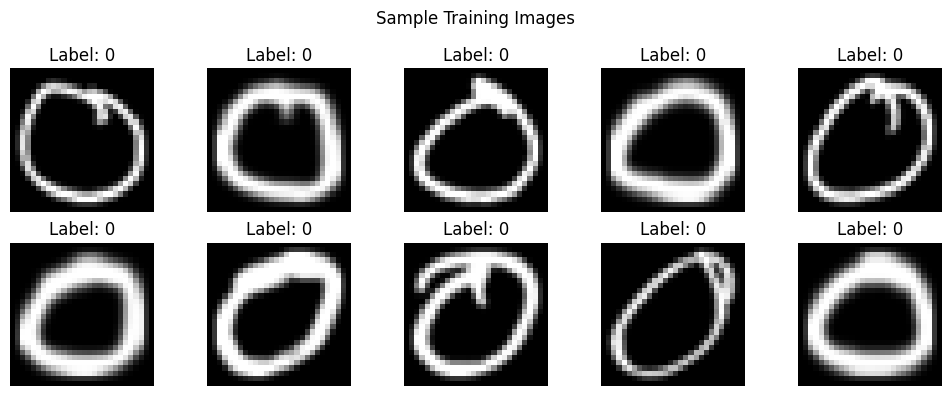

In [22]:
# Visualise sample images from the training set (one per class)
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    plt.title(f'Label: {np.argmax(y_train[i])}')
    plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=12)
plt.tight_layout()
plt.show()

---
## Task 2: Build the FCN Model

Architecture (Sequential):
- Input layer: `(28, 28, 1)`
- Flatten layer: converts 28×28×1 → 784
- Hidden layer 1: **64 neurons**, sigmoid activation
- Hidden layer 2: **128 neurons**, sigmoid activation
- Hidden layer 3: **256 neurons**, sigmoid activation
- Output layer: **10 units**, softmax activation

In [23]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 1)

model = keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        keras.layers.Flatten(),                          # 28x28x1 → 784
        keras.layers.Dense(64,  activation='sigmoid'),   # 1st hidden layer
        keras.layers.Dense(128, activation='sigmoid'),   # 2nd hidden layer
        keras.layers.Dense(256, activation='sigmoid'),   # 3rd hidden layer
        keras.layers.Dense(NUM_CLASSES, activation='softmax'),  # Output layer
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3: Compile the Model

In [24]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully.')
print('  Optimizer : Adam')
print('  Loss      : categorical_crossentropy')
print('  Metrics   : accuracy')

Model compiled successfully.
  Optimizer : Adam
  Loss      : categorical_crossentropy
  Metrics   : accuracy


---
## Task 4: Train the Model

In [25]:
batch_size = 128
epochs     = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='model_at_epoch_{epoch}.keras'
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4
    ),
]

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4789 - loss: 1.6349 - val_accuracy: 0.0000e+00 - val_loss: 7.5885
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8492 - loss: 0.5077 - val_accuracy: 0.0000e+00 - val_loss: 8.9027
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9245 - loss: 0.2686 - val_accuracy: 0.0000e+00 - val_loss: 9.5133
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9502 - loss: 0.1819 - val_accuracy: 0.0000e+00 - val_loss: 9.8285
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9616 - loss: 0.1397 - val_accuracy: 0.0000e+00 - val_loss: 10.2271


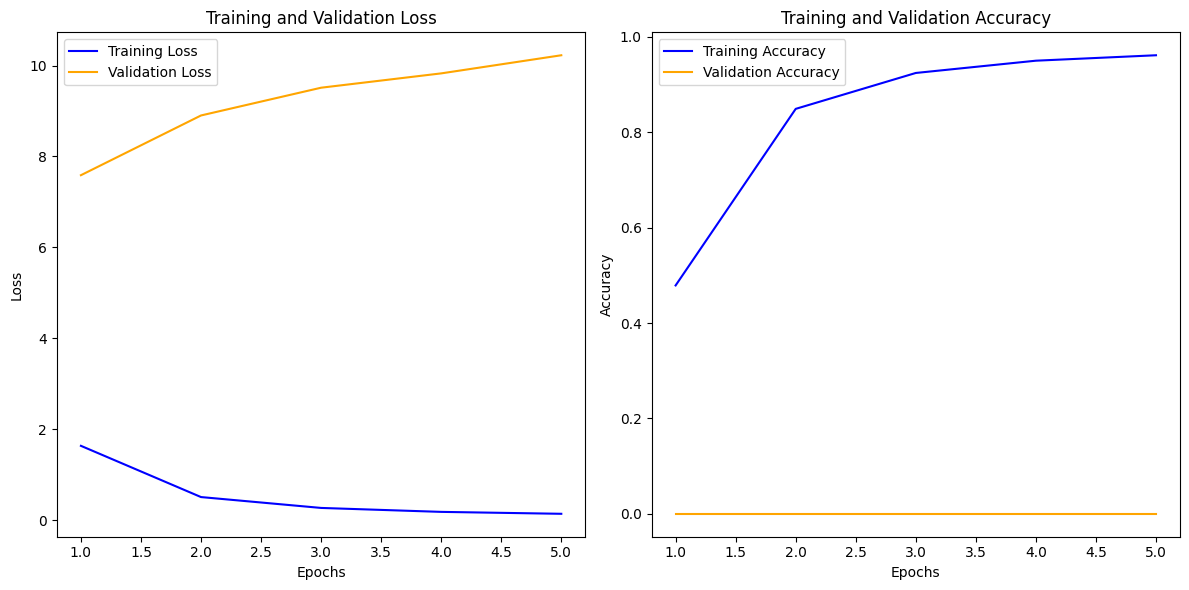

In [26]:
# Visualise training and validation loss and accuracy
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

plt.figure(figsize=(12, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss',   color='blue')
plt.plot(range(1, len(val_loss)   + 1), val_loss,   label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy',   color='blue')
plt.plot(range(1, len(val_acc)   + 1), val_acc,   label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

---
## Task 5: Evaluate the Model

In [27]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

94/94 - 0s - 3ms/step - accuracy: 0.7643 - loss: 2.1660

Test Loss     : 2.1660
Test Accuracy : 0.7643


---
## Task 6: Save and Load the Model

In [28]:
# Save the trained model
model.save('mnist_fully_connected_model.h5')
print('Model saved to: mnist_fully_connected_model.h5')

Model saved to: mnist_fully_connected_model.h5


In [29]:
# Load the saved model
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')
print('Model loaded successfully.')

# Re-evaluate the loaded model on the test set
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f'\nLoaded Model — Test Loss     : {loaded_loss:.4f}')
print(f'Loaded Model — Test Accuracy : {loaded_acc:.4f}')

Model loaded successfully.
94/94 - 1s - 6ms/step - accuracy: 0.7643 - loss: 2.1660

Loaded Model — Test Loss     : 2.1660
Loaded Model — Test Accuracy : 0.7643


---
## Task 7: Make Predictions

In [30]:
# Make predictions on the test data
predictions = model.predict(x_test)

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

# Check the first prediction
print(f'Predicted label for first image: {predicted_labels[0]}')
print(f'True label for first image     : {np.argmax(y_test[0])}')

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted label for first image: 0
True label for first image     : 0


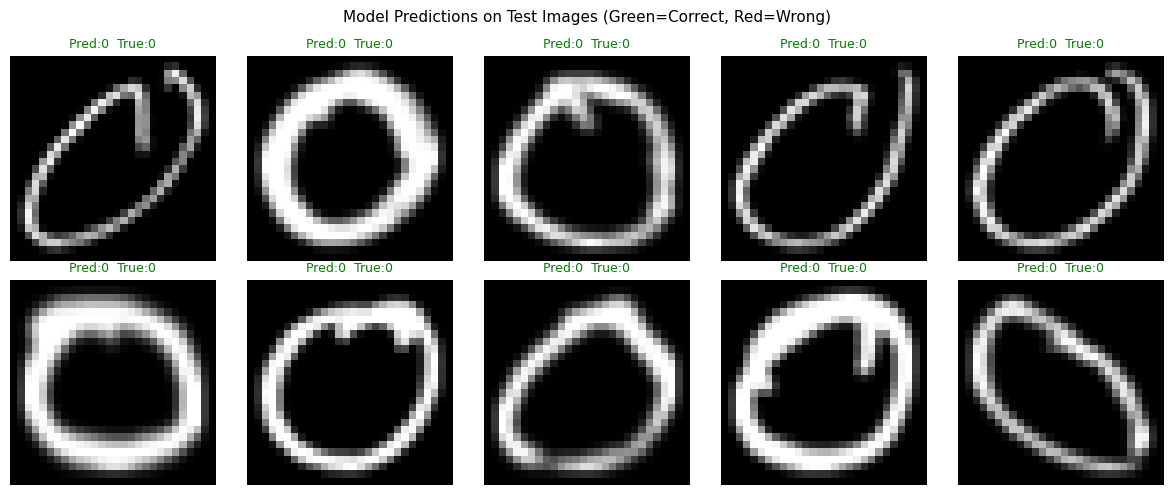

In [31]:
# Visualise the first 10 test images with predicted and true labels
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    true_label = np.argmax(y_test[i])
    pred_label = predicted_labels[i]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f'Pred:{pred_label}  True:{true_label}', color=color, fontsize=9)
    plt.axis('off')
plt.suptitle('Model Predictions on Test Images (Green=Correct, Red=Wrong)', fontsize=11)
plt.tight_layout()
plt.show()